<a href="https://colab.research.google.com/github/whistle-hikhi/Linear-Regression/blob/main/linear_regression_sklearn_cuml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Wed Mar 19 17:08:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%load_ext cuml.accel

[2025-03-19 17:08:53.376] [CUML] [info] cuML: Installed accelerator for sklearn.
[2025-03-19 17:09:28.605] [CUML] [info] cuML: Installed accelerator for umap.
[2025-03-19 17:09:28.694] [CUML] [info] cuML: Installed accelerator for hdbscan.
[2025-03-19 17:09:28.694] [CUML] [info] cuML: Successfully initialized accelerator.


In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [9]:
# Generate same synthetic house price data
np.random.seed(42)
n_samples = 100

square_footage = np.random.uniform(1000, 3000, n_samples)
bedrooms = np.random.randint(2, 6, n_samples)
X = np.column_stack((square_footage, bedrooms))

true_weights = np.array([150, 20000])
true_intercept = 50000
y = X @ true_weights + true_intercept + np.random.normal(0, 10000, n_samples)

# Split data using sklearn's train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
%%time
# Create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

CPU times: user 3.65 ms, sys: 2.08 ms, total: 5.73 ms
Wall time: 14 ms


LinearRegression()


scikit-learn Implementation Results:
Estimated weights: [  150.53178332 20116.92449578]
Estimated intercept: 50132.86296643835
Training MSE: 100396406.49
Test MSE: 81010790.98
R² score: 0.9908


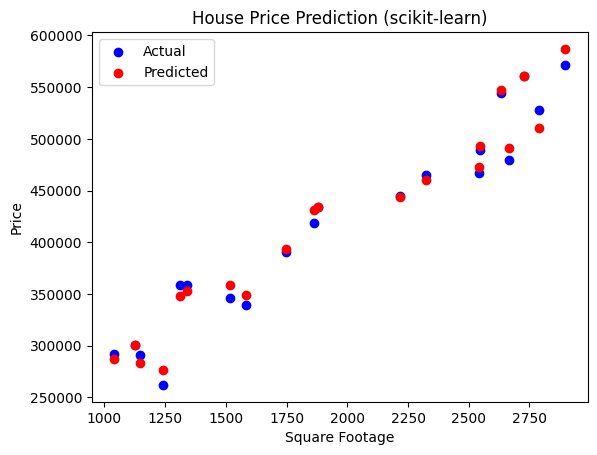

In [11]:

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate MSE
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# Print results
print("\nscikit-learn Implementation Results:")
print(f"Estimated weights: {model.coef_}")
print(f"Estimated intercept: {model.intercept_}")
print(f"Training MSE: {mse_train:.2f}")
print(f"Test MSE: {mse_test:.2f}")
print(f"R² score: {model.score(X_test, y_test):.4f}")

# Visualize predictions vs actual (for square footage only)
plt.scatter(X_test[:, 0], y_test, color='blue', label='Actual')
plt.scatter(X_test[:, 0], y_pred_test, color='red', label='Predicted')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.title('House Price Prediction (scikit-learn)')
plt.legend()
plt.show()